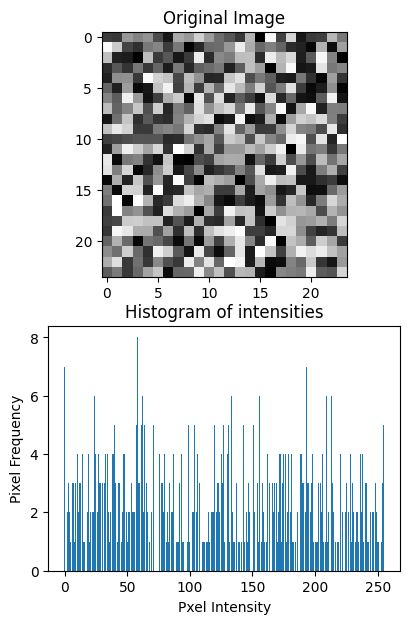

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

array=np.random.randint(0, 256, (24, 24))


plt.figure(figsize=(10,7))
plt.subplot(2,2,1)
plt.title("Original Image")
plt.imshow(array, cmap='gray')

flat_array=array.flatten()

unique_val, counts=np.unique(flat_array, return_counts=True)

plt.subplot(2,2,3)
plt.title("Histogram of intensities")
plt.bar(unique_val, counts)
plt.xlabel("Pxel Intensity")
plt.ylabel("Pixel Frequency")
plt.show()


Task-01: Take a color image and apply 90-degree rotation operation (Without built in image function). Show both input and output image side by side in a subplot with a title.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


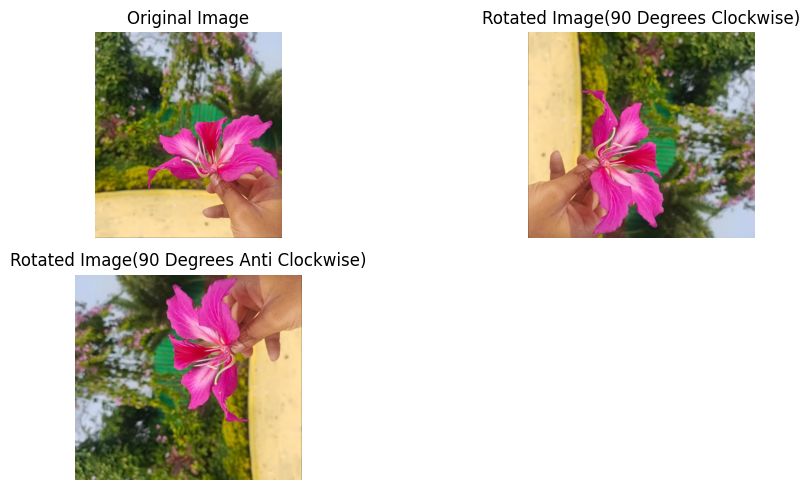

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive

def rotate_image_90(image):
  """Rotate the image 90 degrees clockwise without using built-in functions."""
  width, height=image.size
  new_image=Image.new("RGB", (height, width))

  for y in range(height):
    for x in range(width):
      new_image.putpixel((height-1-y, x), image.getpixel((x, y)))

  return new_image


def rotate_image_90_anti(image):
  width, height=image.size
  new_image=Image.new("RGB", (height, width))

  for y in range(height):
    for x in range(width):
      new_image.putpixel((y, width-1-x), image.getpixel((x,y)))

  return new_image

input_image_path="/content/drive/MyDrive/cse 3216/Screenshot 2025-04-30 220626.png"

image=Image.open(input_image_path)

rotated_image=rotate_image_90(image)

rotated_image_anti=rotate_image_90_anti(image)

plt.figure(figsize=(10,5))

plt.subplot(2,2,1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(rotated_image)
plt.title('Rotated Image(90 Degrees Clockwise)')
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(rotated_image_anti)
plt.title('Rotated Image(90 Degrees Anti Clockwise)')
plt.axis('off')

plt.tight_layout()
plt.show()

Task-02: Take a color image and apply resize operation (200x200) (with and without built in image function). Show both input and output image side by side in a subplot with a title.

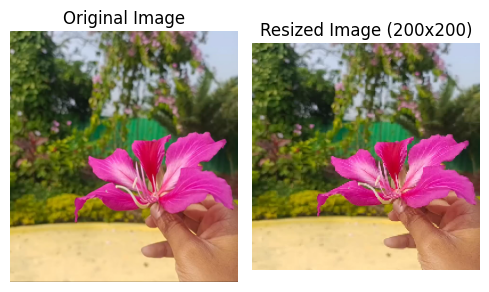

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

def resize_image_manual(image, new_width, new_heigth):
  """Resize the image to the specified dimensions without using built-in functions."""

  original_width, original_height=image.size
  resized_image=Image.new("RGB", (new_width, new_heigth))

  for y in range(new_height):
    for x in range(new_width):
      #calculate the corresponding pixel in the original image
      orig_x=int(x* original_width/new_width)
      orig_y=int(y* original_height/new_height)

      #Get the pixel from the original image and set it in the resized image
      resized_image.putpixel((x,y), image.getpixel((orig_x, orig_y)))

  return resized_image

#Load the color image
input_image_path="/content/drive/MyDrive/cse 3216/Screenshot 2025-04-30 220626.png"
image=Image.open(input_image_path)

#Resize the image
new_width=200
new_height=200
resized_image=resize_image_manual(image, new_width, new_height)

#Plot the original and resized images side by side
plt.figure(figsize=(5,5))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(resized_image)
plt.title(f'Resized Image ({new_width}x{new_height})')
plt.axis('off')
plt.tight_layout()
plt.show()


Task-03: Take a color image and display the output color image that contains only the pixels within the color range we specified. Show both input and output image side by side in a subplot with a title.

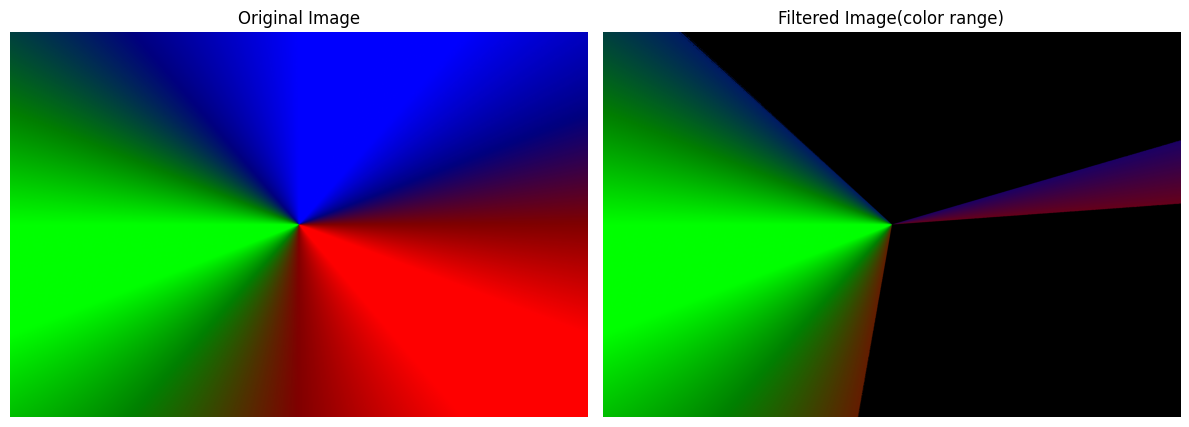

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

input_image_path="/content/drive/MyDrive/cse 3216/rgb.jpg"
image=Image.open(input_image_path)
image_np=np.array(image)

lower_color=np.array([0,0,0])
upper_color=np.array([100,255,100])

mask=np.all((image_np>=lower_color)& (image_np<=upper_color), axis=-1)

output_image_np=np.zeros_like(image_np)
output_image_np[mask]=image_np[mask]
output_image=Image.fromarray(output_image_np)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output_image)
plt.title('Filtered Image(color range)')
plt.axis('off')
plt.tight_layout()
plt.show()


Task-04: Take a color image and identify output color image that contains only the green/red/blue pixels. Show both input and output image side by side in a subplot with a title.

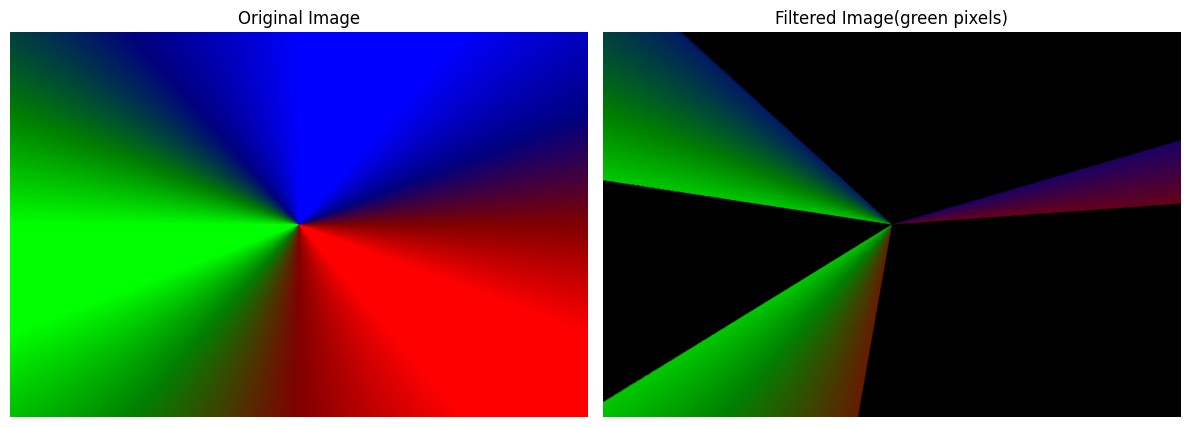

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

input_image_path="/content/drive/MyDrive/cse 3216/rgb.jpg"
image=Image.open(input_image_path)
image_np=np.array(image)

lower_green=np.array([0,0,0])
upper_green=np.array([100,200,100])

mask=np.all((image_np >=lower_green)&(image_np<=upper_green), axis=-1)

output_image_np=np.zeros_like(image_np)
output_image_np[mask]=image_np[mask]

output_image=Image.fromarray(output_image_np)

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(output_image)
plt.title('Filtered Image(green pixels)')
plt.axis('off')
plt.tight_layout()
plt.show()

Task-05: Take a color image and separate the red, green and blue component of the image. Show both input and output image(red, green and blue component) side by side in a subplot with a title. Also reconstruct the original  olor image from its red, green and blue component. Show both input (red, green and blue component) and output image (original image) side by side in a subplot with a title.

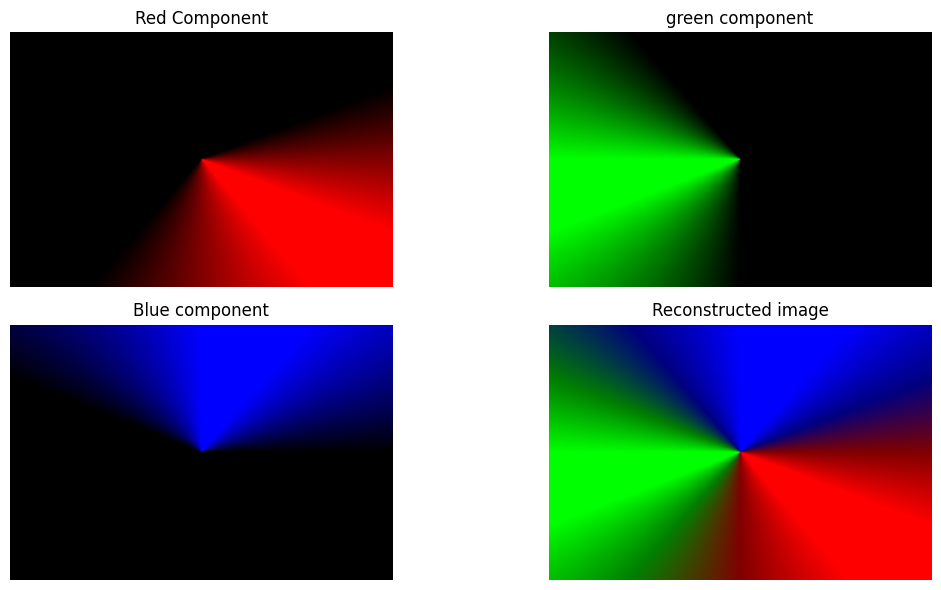

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

input_image_path="/content/drive/MyDrive/cse 3216/rgb.jpg"
image=Image.open(input_image_path)
image_np=np.array(image)

red_component=image_np.copy()
green_component=image_np.copy()
blue_component=image_np.copy()

red_component[:,:,1]=0
red_component[:,:,2]=0

green_component[:,:,0]=0
green_component[:,:,2]=0

blue_component[:,:,0]=0
blue_component[:,:,1]=0

red_image=Image.fromarray(red_component)
green_image=Image.fromarray(green_component)
blue_image=Image.fromarray(blue_component)

reconstructed_image=Image.fromarray(image_np)

plt.figure(figsize=(12,6))
plt.subplot(2,2,1)
plt.imshow(red_image)
plt.title('Red Component')
plt.axis('off')

plt.subplot(2,2,2)
plt.title('green component')
plt.imshow(green_image)
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(blue_image)
plt.title('Blue component')
plt.axis('off')
plt.subplot(2,2,4)
plt.imshow(reconstructed_image)
plt.title('Reconstructed image')
plt.axis('off')

plt.tight_layout()
plt.show()


Task-06: Take a color image and plot the histogram of the image. Show both input and output image side by side in a subplot with a title.

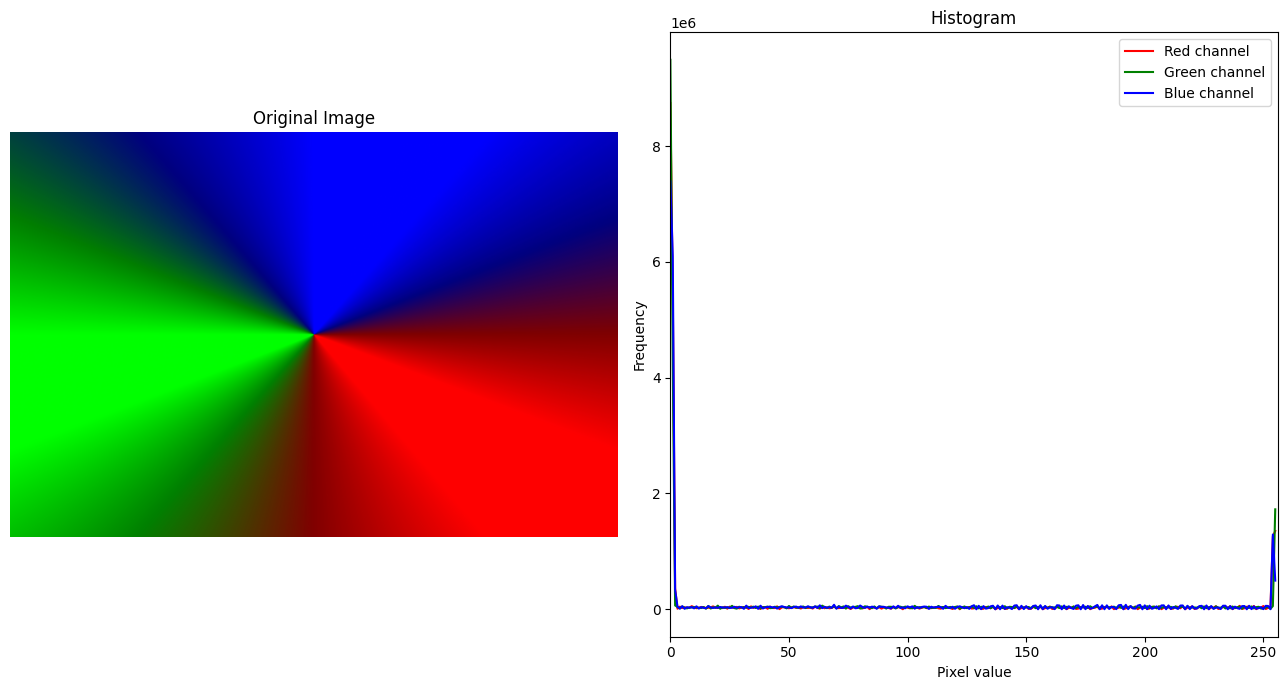

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

input_image_path="/content/drive/MyDrive/cse 3216/rgb.jpg"
image=Image.open(input_image_path)
image_np=np.array(image)

red_channel=image_np[:,:,0]
green_channel=image_np[:,:,1]
blue_channel=image_np[:,:,2]

red_hist,bins_red=np.histogram(red_channel.flatten(), bins=256, range=[0,256])
green_hist, bins_green=np.histogram(green_channel.flatten(), bins=256, range=[0,256])
blue_hist, bins_blue=np.histogram(blue_channel.flatten(), bins=256, range=[0,256])

plt.figure(figsize=(13,7))
plt.subplot(1,2,1)
plt.imshow(image)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1,2,2)
plt.plot(bins_red[:-1], red_hist, color='red', label='Red channel')
plt.plot(bins_green[:-1], green_hist, color='green', label='Green channel')
plt.plot(bins_blue[:-1], blue_hist, color='blue', label='Blue channel')

plt.title('Histogram')
plt.xlabel('Pixel value')
plt.ylabel('Frequency')
plt.legend()
plt.xlim([0,256])
plt.tight_layout()
plt.show()